# Laboratorio 4 — Análisis de Datos GeoEspaciales
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


## Ejercicio 1. Conexión con el API de Sentinel-2 (openEO)

Usamos el backend openEO de la **Copernicus Data Space Ecosystem (CDSE)**, que es el
punto de acceso oficial (gratuito, con cuenta Copernicus) a las colecciones de
Sentinel-2 L2A. La autenticación es OIDC (abre una ventana/URL de login la primera vez
y luego cachea el token localmente).

In [1]:
# Si no lo tienes instalado:
# %pip install openeo geopandas shapely matplotlib pandas --quiet

import openeo
from pathlib import Path
import pandas as pd

# --- Conexión al backend openEO de Copernicus Data Space Ecosystem ---
OPENEO_URL = "https://openeo.dataspace.copernicus.eu"

connection = openeo.connect(OPENEO_URL)

# Autenticación OIDC: la primera vez abrirá una URL/navegador para iniciar sesión
# con tu usuario y contraseña de Copernicus. El token queda cacheado para las
# siguientes ejecuciones (no es necesario volver a loguearse cada vez).
connection.authenticate_oidc()

print("Conectado a:", OPENEO_URL)
print("Usuario autenticado correctamente.")

Authenticated using refresh token.
Conectado a: https://openeo.dataspace.copernicus.eu
Usuario autenticado correctamente.


In [2]:
# Verificamos que la colección Sentinel-2 L2A esté disponible en el backend
colecciones = connection.list_collection_ids()
assert "SENTINEL2_L2A" in colecciones, "La colección SENTINEL2_L2A no está disponible en este backend"
print("Colección SENTINEL2_L2A disponible. Listo para continuar.")

Colección SENTINEL2_L2A disponible. Listo para continuar.


## Ejercicio 2. Obtención de los datos raster necesarios

Para reducir tiempos de descarga y almacenamiento, **solo se descargan las bandas
necesarias para calcular NDVI y NDWI**:

- **NDVI:** `B04` (rojo) y `B08` (infrarrojo cercano)
- **NDWI:** `B03` (verde) y `B08` (infrarrojo cercano)

Es decir, con las tres bandas `B03`, `B04`, `B08` cubrimos ambos índices en una sola
descarga por imagen (evitamos descargar la escena completa).

Usamos exclusivamente:
- Las coordenadas (bounding box) de cada lago dadas en el enunciado.
- Las fechas oficiales de la tabla del laboratorio (11 fechas por lago).

In [3]:
# --- Coordenadas de cada lago (dadas en el enunciado del laboratorio) ---
lagos_bbox = {
    "atitlan": {
        "west": -91.326256,
        "east": -91.07151,
        "south": 14.5948,
        "north": 14.750979,
    },
    "amatitlan": {
        "west": -90.638065,
        "east": -90.512924,
        "south": 14.412347,
        "north": 14.493799,
    },
}

# --- Fechas oficiales por lago (tal como las proporciona el laboratorio) ---
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

fechas_por_lago = {
    "atitlan": fechas_atitlan,
    "amatitlan": fechas_amatitlan,
}

for lago, fechas in fechas_por_lago.items():
    print(f"{lago}: {len(fechas)} fechas oficiales")

atitlan: 11 fechas oficiales
amatitlan: 11 fechas oficiales


In [4]:
# --- Bandas mínimas necesarias: B03 (verde), B04 (rojo), B08 (NIR) ---
BANDAS = ["B03", "B04", "B08"]

# Carpeta de salida para los raster descargados
OUTPUT_DIR = Path("data/raster")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def siguiente_dia(fecha_str: str) -> str:
    """Devuelve la fecha siguiente en formato YYYY-MM-DD (para construir un
    rango temporal de un solo día, requerido por openEO)."""
    fecha = pd.to_datetime(fecha_str)
    return (fecha + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def descargar_imagen(lago: str, fecha: str, bbox: dict, bandas=BANDAS,
                      max_cloud_cover: float = 20.0) -> Path:
    """Descarga únicamente las bandas necesarias para una fecha y un lago
    dados, usando el bounding box provisto. Guarda el resultado como GeoTIFF.
    """
    destino = OUTPUT_DIR / lago / f"{lago}_{fecha}.tif"
    destino.parent.mkdir(parents=True, exist_ok=True)

    # Solo omitimos si el archivo ya existe Y no está corrupto (tamaño > 0).
    if destino.exists() and destino.stat().st_size > 0:
        print(f"[omitido] Ya existe: {destino}")
        return destino

    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, siguiente_dia(fecha)],
        bands=bandas,
        max_cloud_cover=max_cloud_cover,
    )

    # Nos quedamos con la mediana temporal por si hay más de una escena en
    # el rango (debería ser una sola, dado que el rango es de un día)
    datacube = datacube.reduce_dimension(dimension="t", reducer="median")

    print(f"Descargando {lago} - {fecha} ...")
    datacube.download(str(destino))
    print(f"  -> guardado en {destino}")
    return destino

In [5]:
# --- Descarga de todas las imágenes (solo bandas necesarias) para ambos lagos ---
rutas_descargadas = []

for lago, bbox in lagos_bbox.items():
    for fecha in fechas_por_lago[lago]:
        ruta = descargar_imagen(lago, fecha, bbox)
        rutas_descargadas.append({"lago": lago, "fecha": fecha, "ruta": str(ruta)})

df_descargas = pd.DataFrame(rutas_descargadas)
df_descargas

[omitido] Ya existe: data/raster/atitlan/atitlan_2025-01-18.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-04-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-05-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-07-17.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-11-21.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-12-29.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-02-12.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-03-24.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-28.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-07-22.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-01-28.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-15.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-28.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-11-24.tif
[omitido] Ya existe: dat

,lago,fecha,ruta
0,atitlan,2025-01-18,data/raster/atitlan/atitlan_2025-01-18.tif
1,atitlan,2025-04-13,data/raster/atitlan/atitlan_2025-04-13.tif
2,atitlan,2025-05-13,data/raster/atitlan/atitlan_2025-05-13.tif
3,atitlan,2025-07-17,data/raster/atitlan/atitlan_2025-07-17.tif
4,atitlan,2025-11-21,data/raster/atitlan/atitlan_2025-11-21.tif
5,atitlan,2025-12-29,data/raster/atitlan/atitlan_2025-12-29.tif
6,atitlan,2026-02-12,data/raster/atitlan/atitlan_2026-02-12.tif
7,atitlan,2026-03-24,data/raster/atitlan/atitlan_2026-03-24.tif
8,atitlan,2026-04-13,data/raster/atitlan/atitlan_2026-04-13.tif
9,atitlan,2026-04-28,data/raster/atitlan/atitlan_2026-04-28.tif


In [6]:
# Guardamos el índice de archivos descargados para usarlo en los siguientes
# ejercicios (cálculo de índices, análisis temporal y espacial)
df_descargas.to_csv("data/indice_descargas.csv", index=False)
print("Total de imágenes descargadas:", len(df_descargas))
df_descargas.groupby("lago").size()

Total de imágenes descargadas: 22


lago
amatitlan    11
atitlan      11
dtype: int64

## Ejercicio 3.

descarga solo B05 (rápido, ~22 imágenes de 1 banda)

In [7]:
BANDA_EXTRA = "B05"

def descargar_banda_extra(lago, fecha, bbox, banda=BANDA_EXTRA, max_cloud_cover=20.0):
    destino = OUTPUT_DIR / lago / f"{lago}_{fecha}_{banda}.tif"
    destino.parent.mkdir(parents=True, exist_ok=True)
    # Solo omitimos si el archivo ya existe Y no está corrupto (tamaño > 0).
    if destino.exists() and destino.stat().st_size > 0:
        print(f"[omitido] Ya existe: {destino}")
        return destino
    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, siguiente_dia(fecha)],
        bands=[banda],
        max_cloud_cover=max_cloud_cover,
    )
    datacube = datacube.reduce_dimension(dimension="t", reducer="median")
    print(f"Descargando {lago} - {fecha} - {banda} ...")
    datacube.download(str(destino))
    return destino

rutas_b05 = []
for lago, bbox in lagos_bbox.items():
    for fecha in fechas_por_lago[lago]:
        ruta = descargar_banda_extra(lago, fecha, bbox)
        rutas_b05.append({"lago": lago, "fecha": fecha, "ruta_b05": str(ruta)})

df_b05 = pd.DataFrame(rutas_b05)
df_descargas = df_descargas.merge(df_b05, on=["lago", "fecha"])

[omitido] Ya existe: data/raster/atitlan/atitlan_2025-01-18_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-04-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-05-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-07-17_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-11-21_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-12-29_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-02-12_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-03-24_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-28_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-07-22_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-01-28_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-15_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-28_B05.tif
[omitido] Ya existe: data/raster/ama

funciones para NDVI, NDWI y cianobacteria (NDCI/Chl-a)

In [8]:
import rasterio
import numpy as np

def leer_bandas(ruta_principal, ruta_b05):
    with rasterio.open(ruta_principal) as src:
        b03 = src.read(1).astype("float32")
        b04 = src.read(2).astype("float32")
        b08 = src.read(3).astype("float32")
    with rasterio.open(ruta_b05) as src2:
        b05 = src2.read(1).astype("float32")
    return b03, b04, b08, b05

def calcular_indices(b03, b04, b08, b05):
    NODATA = -1000
    for b in (b03, b04, b08, b05):
        b[:] = np.where(b <= NODATA, np.nan, b) / 10000.0
    b03, b04, b08, b05 = (np.clip(b, 0.0, 1.0) for b in (b03, b04, b08, b05))

    eps = 1e-6
    ndvi = (b08 - b04) / (b08 + b04 + eps)
    ndwi = (b03 - b08) / (b03 + b08 + eps)
    ndci = (b05 - b04) / (b05 + b04 + eps)
    
    ndci = np.clip(ndci, -1.0, 1.0)
    with np.errstate(over="ignore"):
        chl_a = 17.441 * np.exp(4.7038 * ndci)
    return ndvi, ndwi, chl_a

def mascara_agua(ndwi, umbral=0.0):
    return ndwi > umbral


calcular índices para todas las imágenes

In [ ]:
# Optimización de carga: cada imagen se lee del disco UNA sola vez aquí y los
# arrays derivados (NDVI, NDWI, Chl-a, máscara de agua) se guardan en memoria
# en CACHE_RASTER. Las celdas siguientes (mapas, comparaciones, correlaciones,
# ejercicios 7 y 8) reutilizan este cache en lugar de volver a abrir los GeoTIFF.
CACHE_RASTER = {}  # (lago, fecha) -> {"ndvi":..., "ndwi":..., "chl":..., "agua":...}

resultados = []
for _, fila in df_descargas.iterrows():
    b03, b04, b08, b05 = leer_bandas(fila["ruta"], fila["ruta_b05"])
    ndvi, ndwi, chl_a = calcular_indices(b03, b04, b08, b05)
    agua = mascara_agua(ndwi)

    CACHE_RASTER[(fila["lago"], fila["fecha"])] = {
        "ndvi": ndvi, "ndwi": ndwi, "chl": chl_a, "agua": agua,
    }

    resultados.append({
        "lago": fila["lago"],
        "fecha": fila["fecha"],
        "ndvi_prom": np.nanmean(ndvi[agua]),
        "ndwi_prom": np.nanmean(ndwi[agua]),
        "cianobacteria_prom": np.nanmean(chl_a[agua]),
        "pct_agua": float(np.nanmean(agua)) * 100,
    })

df_indices = pd.DataFrame(resultados)
df_indices["fecha"] = pd.to_datetime(df_indices["fecha"])
df_indices = df_indices.sort_values(["lago", "fecha"])
df_indices.to_csv("data/indices_por_imagen.csv", index=False)
print(f"Imágenes procesadas y cacheadas en memoria: {len(CACHE_RASTER)}")
df_indices


mapa del índice de cianobacteria por lago (pide la rúbrica)

In [ ]:
import matplotlib.pyplot as plt

for lago in lagos_bbox:
    fila = df_descargas[df_descargas["lago"] == lago].iloc[0]
    chl_a = CACHE_RASTER[(lago, fila["fecha"])]["chl"]  # reutiliza el cache, sin releer el archivo

    plt.figure(figsize=(6, 5))
    plt.imshow(chl_a, cmap="RdYlGn_r")
    plt.colorbar(label="Chl-a (cianobacteria)")
    plt.title(f"Índice de cianobacteria — {lago} ({fila['fecha']})")
    plt.axis("off")
    plt.show()


## Ejercicio 4: análisis temporal

4.1 Promedio de cianobacteria (Chl-a, µg/L) por lago y fecha:


,lago,fecha,ndvi_prom,ndwi_prom,cianobacteria_prom,pct_agua
11,amatitlan,2025-01-28,-0.355559,0.557307,63.135151,12.664459
12,amatitlan,2025-04-15,-0.089175,0.274155,37.245308,12.260248
13,amatitlan,2025-04-28,-0.061108,0.275404,47.775261,11.922109
14,amatitlan,2025-11-24,-0.367940,0.505837,47.581120,12.376997
15,amatitlan,2026-01-08,-0.124587,0.380934,70.882065,11.470508
16,amatitlan,2026-02-02,-0.063483,0.173837,33.065250,11.207422
17,amatitlan,2026-02-07,-0.428903,0.605405,45.711452,6.292177
18,amatitlan,2026-03-29,-0.070838,0.297668,57.773796,12.546106
19,amatitlan,2026-04-13,-0.026536,0.267751,67.103966,12.717862
20,amatitlan,2026-04-28,-0.045621,0.315232,58.496460,10.606999


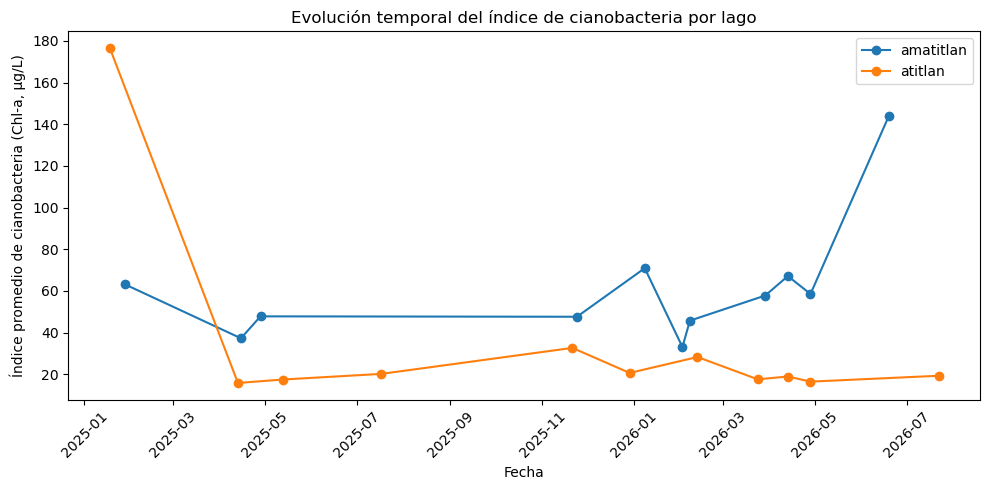

4.3 Pico de floración (máximo de Chl-a) por lago:


,lago,fecha,cianobacteria_prom
21,amatitlan,2026-06-19,143.946854
0,atitlan,2025-01-18,176.531799


Resumen estadístico por lago:


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,11.0,61.156063,29.948950,33.065250,46.646286,57.773796,65.119558,143.946854
atitlan,11.0,34.871090,47.267529,15.795756,17.506315,19.254324,24.432283,176.531799


In [11]:
print("4.1 Promedio de cianobacteria (Chl-a, µg/L) por lago y fecha:")
display(df_indices)

plt.figure(figsize=(10, 5))
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago]
    plt.plot(sub["fecha"], sub["cianobacteria_prom"], marker="o", label=lago)

plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria (Chl-a, µg/L)")
plt.title("Evolución temporal del índice de cianobacteria por lago")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/evolucion_temporal_cianobacteria.png")
plt.show()

picos = df_indices.loc[df_indices.groupby("lago")["cianobacteria_prom"].idxmax()]
print("4.3 Pico de floración (máximo de Chl-a) por lago:")
display(picos[["lago", "fecha", "cianobacteria_prom"]])

print("Resumen estadístico por lago:")
display(df_indices.groupby("lago")["cianobacteria_prom"].describe())

### 4.4 Interpretación de los patrones temporales

- **Atitlán:** la cianobacteria se mantiene baja y estable casi todo el período (mediana ≈ 19 µg/L),
  con un solo evento extremo el **2025-01-18 (≈177 µg/L)**. El patrón no es de tendencia sino de
  un bloom aislado.
- **Amatitlán:** nivel de fondo más alto (mediana ≈ 58 µg/L), fluctuante y **en aumento en 2026**,
  con pico en **2026-06-19 (≈144 µg/L)**.
- **Fechas críticas:** Atitlán → 2025-01-18; Amatitlán → 2026-06-19 (y 2026-01-08).
- **Posibles factores:** el pico de Amatitlán coincide con el inicio de la temporada lluviosa
  (mayo–junio), cuando el escurrimiento arrastra nutrientes a un lago eutrófico y poco profundo.
  El bloom de Atitlán coincide con el final de la temporada seca y altas temperaturas.
  En ambos casos, el aporte de nutrientes y el calor son los disparadores más probables.

## Ejercicio 5: Análisis espacial

Mapas de la distribución de cianobacteria dentro de cada lago. Los valores se calculan
con las mismas funciones de los ejercicios 3–4 (Chl-a sobre píxeles de agua) y se
reproyectan a WGS84 para poder superponerlos sobre un mapa base interactivo.

In [ ]:
from rasterio.warp import reproject, Resampling, transform_bounds, calculate_default_transform
import folium

def chl_reproyectado(lago, fecha, ruta):
    # Chl-a y NDWI ya están en CACHE_RASTER (no se vuelven a leer las bandas);
    # solo se abre el archivo para su metadata geoespacial (rápido, sin leer píxeles).
    chl = CACHE_RASTER[(lago, fecha)]["chl"]
    ndwi = CACHE_RASTER[(lago, fecha)]["ndwi"]
    chl = np.where(mascara_agua(ndwi), chl, np.nan)
    with rasterio.open(ruta) as src:
        crs, transform, W, H, bounds = src.crs, src.transform, src.width, src.height, src.bounds
    dst_crs = "EPSG:4326"
    dst_t, dst_w, dst_h = calculate_default_transform(crs, dst_crs, W, H, *bounds)
    dst = np.full((dst_h, dst_w), np.nan, dtype="float32")
    reproject(chl, dst, src_transform=transform, src_crs=crs, src_nodata=np.nan,
              dst_transform=dst_t, dst_crs=dst_crs, dst_nodata=np.nan,
              resampling=Resampling.bilinear)
    geo = transform_bounds(crs, dst_crs, *bounds)
    return dst, dst_t, geo

def vmax_chl(lago, fecha, pct=95.0):
    chl = CACHE_RASTER[(lago, fecha)]["chl"]
    ndwi = CACHE_RASTER[(lago, fecha)]["ndwi"]
    return float(np.nanpercentile(chl[mascara_agua(ndwi)], pct))

def rgba_chl(dst, vmax):
    cmap = plt.get_cmap("RdYlGn_r").copy()
    cmap.set_bad("none")
    return (np.rint(cmap(np.clip(dst, 0, vmax) / vmax) * 255)).astype("uint8")

def mapa_folium_chl(lago, fecha, ruta, vmax):
    dst, dst_t, geo = chl_reproyectado(lago, fecha, ruta)
    lat0, lon0, lat1, lon1 = geo[1], geo[0], geo[3], geo[2]
    m = folium.Map(location=[(lat0 + lat1) / 2, (lon0 + lon1) / 2], zoom_start=11,
                   tiles="CartoDB positron")
    folium.raster_layers.ImageOverlay(rgba_chl(dst, vmax),
                                      bounds=[[lat0, lon0], [lat1, lon1]],
                                      opacity=0.85).add_to(m)
    y, x = np.unravel_index(np.nanargmax(dst), dst.shape)
    lon_max, lat_max = rasterio.transform.xy(dst_t, y, x)
    folium.CircleMarker([lat_max, lon_max], radius=6, color="black", weight=2,
                        fill=True, fill_color="white",
                        popup=f"{lago} — {fecha} — máx Chl-a").add_to(m)
    return m

for lago in df_indices["lago"].unique():
    pico = picos[picos["lago"] == lago].iloc[0]
    fecha_pico = pico["fecha"].strftime("%Y-%m-%d")
    fila = df_descargas[(df_descargas["lago"] == lago) & (df_descargas["fecha"] == fecha_pico)].iloc[0]
    vmax = vmax_chl(lago, fecha_pico)
    m = mapa_folium_chl(lago, fecha_pico, fila["ruta"], vmax)
    archivo = f"data/mapa_chl_{lago}.html"
    m.save(archivo)
    print(f"{lago}: mapa interactivo en {archivo} (fecha pico {fecha_pico}, escala p95 = {vmax:.0f} µg/L)")
    display(m)


### 5.2 Mapas comparativos entre fechas
Se comparan las 11 fechas por lago con una escala de color común.

In [ ]:
ncols = 4
for lago in df_indices["lago"].unique():
    fechas = sorted(df_indices[df_indices["lago"] == lago]["fecha"])
    n = len(fechas)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    cmap = plt.get_cmap("RdYlGn_r").copy()
    cmap.set_bad("none")
    im = None
    for ax, fecha in zip(axes, fechas):
        f_str = fecha.strftime("%Y-%m-%d")
        c = CACHE_RASTER[(lago, f_str)]  # reutiliza el cache en vez de releer + recalcular
        chl_m = np.where(c["agua"], c["chl"], np.nan)
        vmax = vmax_chl(lago, f_str)
        im = ax.imshow(chl_m, cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(f_str, fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Distribución de cianobacteria (Chl-a, µg/L) — {lago} (escala propia por fecha)", fontsize=12)
    fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="Chl-a (µg/L, escala por fecha)")
    plt.tight_layout()
    plt.savefig(f"data/mapas_comparativos_{lago}.png")
    plt.show()


### 5.3 Interpretación de los patrones espaciales

- **Atitlán:** los valores altos se concentran en la parte **centro-norte** del lago y bajan
  hacia el sur (centro-norte ≈ 38 µg/L vs. sur ≈ 18 µg/L), pero la zona del máximo **cambia
  entre fechas** (p. ej., el bloom del 2025-01-18 en el centro-oeste). No hay zona fija de acumulación.
- **Amatitlán:** las concentraciones se concentran en el **centro del lago** (centro ≈ 65–69 µg/L
  vs. bordes ≈ 24–34 µg/L). Los máximos suelen aparecer en el **extremo sur** (2025-01-28 y
  2026-02-07, zona de ingreso de nutrientes) o en el centro-noreste (2026-06-19).
- **Patrón general:** en ambos lagos la cianobacteria no se reparte de forma uniforme; se acumula
  en sectores específicos (centro-norte en Atitlán; centro y extremo sur en Amatitlán) y esa zona
  se desplaza entre fechas, probablemente por viento, corrientes y aportes puntuales de nutrientes.

## Ejercicio 6: Correlación de los índices (NDVI y NDWI) con la cianobacteria

Se correlaciona el NDVI y el NDWI con la concentración de cianobacteria (Chl-a, µg/L)
a dos niveles: **temporal** (medias por fecha, n = 11 por lago) y **espacial**
(todos los píxeles de agua agrupados de todas las fechas).

Correlación temporal (medias por fecha) entre índices y Chl-a:


,lago,índice,n fechas,Pearson r,p (Pearson),Spearman rho,p (Spearman)
0,amatitlan,NDVI,11,-0.054,0.8736,0.082,0.8110
1,amatitlan,NDWI,11,0.367,0.2671,0.318,0.3403
2,atitlan,NDVI,11,0.872,0.0005,-0.009,0.9788
3,atitlan,NDWI,11,0.678,0.0219,0.845,0.0010


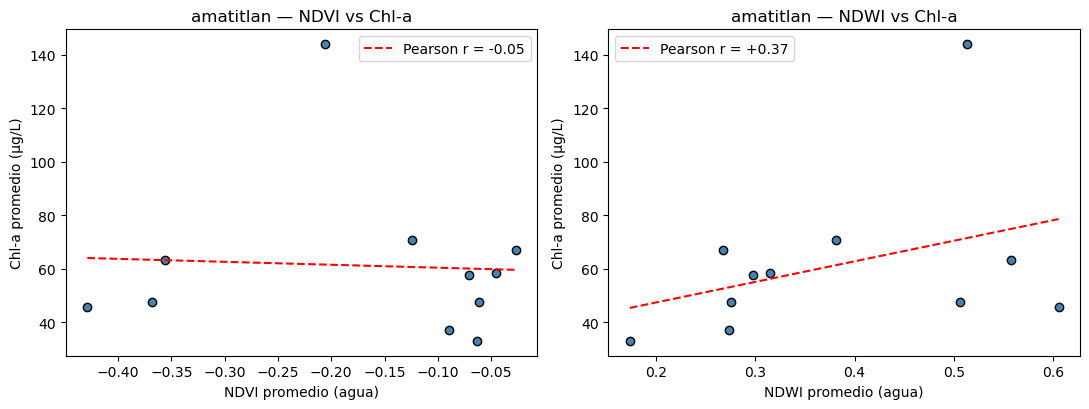

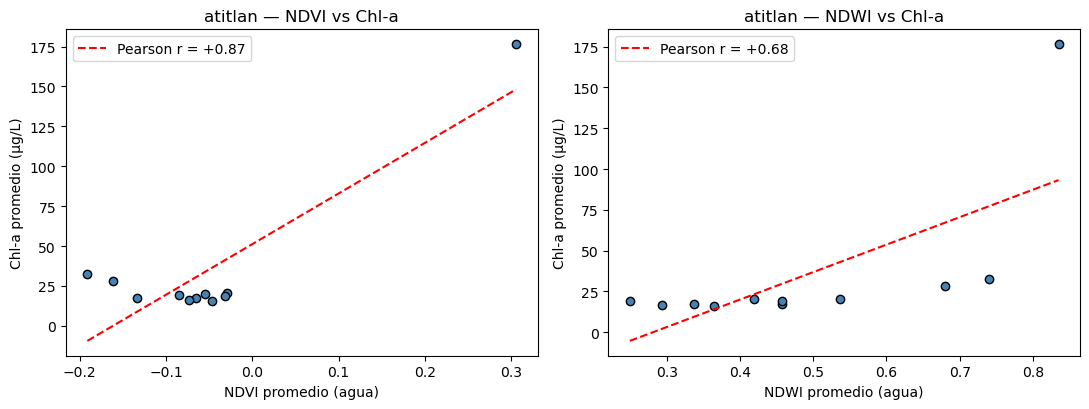

In [ ]:
from scipy.stats import pearsonr, spearmanr

filas_corr = []
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago].dropna()
    for ind, nombre in [("ndvi_prom", "NDVI"), ("ndwi_prom", "NDWI")]:
        r, p = pearsonr(sub[ind], sub["cianobacteria_prom"])
        rs, ps = spearmanr(sub[ind], sub["cianobacteria_prom"])
        filas_corr.append({
            "lago": lago, "índice": nombre, "n fechas": len(sub),
            "Pearson r": round(r, 3), "p (Pearson)": round(p, 4),
            "Spearman rho": round(rs, 3), "p (Spearman)": round(ps, 4),
        })
df_corr = pd.DataFrame(filas_corr)
print("Correlación temporal (medias por fecha) entre índices y Chl-a:")
display(df_corr)

for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, ind, nombre in zip(axes, ["ndvi_prom", "ndwi_prom"], ["NDVI", "NDWI"]):
        ax.scatter(sub[ind], sub["cianobacteria_prom"], c="steelblue", edgecolor="k")
        m, b = np.polyfit(sub[ind], sub["cianobacteria_prom"], 1)
        xs = np.linspace(sub[ind].min(), sub[ind].max(), 50)
        r_p, _ = pearsonr(sub[ind], sub["cianobacteria_prom"])
        ax.plot(xs, m * xs + b, "r--", label=f"Pearson r = {r_p:+.2f}")
        ax.set_xlabel(f"{nombre} promedio (agua)")
        ax.set_ylabel("Chl-a promedio (µg/L)")
        ax.set_title(f"{lago} — {nombre} vs Chl-a")
        ax.legend()
    plt.tight_layout()
    plt.savefig(f"data/correlacion_{lago}.png", dpi=120)
    plt.show()

In [ ]:
filas_pixel = []
for lago in df_indices["lago"].unique():
    N_all, W_all, C_all = [], [], []
    for (lg, fecha), c in CACHE_RASTER.items():  # reutiliza el cache en vez de releer los raster
        if lg != lago:
            continue
        N_all.append(c["ndvi"][c["agua"]]); W_all.append(c["ndwi"][c["agua"]]); C_all.append(c["chl"][c["agua"]])
    N = np.concatenate(N_all); W = np.concatenate(W_all); C = np.concatenate(C_all)
    ok = np.isfinite(N) & np.isfinite(W) & np.isfinite(C)
    N, W, C = N[ok], W[ok], C[ok]
    for nombre, X in [("NDVI", N), ("NDWI", W)]:
        r, p = pearsonr(X, C)
        rs, ps = spearmanr(X, C)
        filas_pixel.append({
            "lago": lago, "índice": nombre, "n píxeles": f"{len(X) / 1e6:.1f} M",
            "Pearson r": round(r, 3), "p": f"{p:.1e}", "Spearman rho": round(rs, 3),
        })
df_corr_pixel = pd.DataFrame(filas_pixel)
print("Correlación espacial (píxeles de agua, todas las fechas agrupadas):")
display(df_corr_pixel)


### 6.1 Explicación de los hallazgos

**Resumen (relación débil a moderada, siempre de signo positivo):**

- **Atitlán:** el **NDWI se correlaciona de forma positiva y significativa** con la cianobacteria
  (Spearman +0.845, p = 0.001): cuando aparece el bloom sube la reflectancia verde (B03) y el NDWI.
  Significado: el NDWI sirve como indicador del estado algal en un lago con agua clara la mayor
  parte del año. El **NDVI parece correlacionar** (Pearson +0.87) pero **es espurio**: lo domina
  el outlier del 2025-01-18; sin él no hay relación (Spearman ≈ 0), porque sobre agua el NDVI
  solo responde en blooms extremos.
- **Amatitlán:** correlaciones **débiles y no significativas** (NDWI ≈ +0.3, NDVI ≈ 0). El lago es
  eutrófico y permanentemente turbio, con poco contraste entre fechas, así que ningún índice
  distingue bien los niveles de cianobacteria (y n = 11 es poco).
- **Nivel espacial (píxeles):** el NDVI correlaciona positivamente dentro de cada lago (Atitlán
  rho = +0.44, Amatitlán +0.26) porque comparte la banda roja (B04) con el NDCI usado para el Chl-a;
  el NDWI espacial es casi nulo.

**Conclusión:** la relación entre los índices y la cianobacteria es **positiva pero débil**; solo el
NDWI en Atitlán es concluyente. El NDVI no es confiable (responde solo en blooms extremos) y en
Amatitlán la eutrofización permanente impide detectar la relación.

## Ejercicio 7. Análisis y comparación de los lagos

In [ ]:
from scipy.stats import linregress

filas_resumen = []
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago].sort_values("fecha")
    x_dias = (sub["fecha"] - sub["fecha"].min()).dt.days.values
    y = sub["cianobacteria_prom"].values
    pendiente, intercepto, r, p, se = linregress(x_dias, y)
    filas_resumen.append({
        "lago": lago,
        "media (µg/L)": np.mean(y),
        "mediana (µg/L)": np.median(y),
        "desv. estándar": np.std(y),
        "CV (%)": 100 * np.std(y) / np.mean(y),
        "mínimo": np.min(y),
        "máximo": np.max(y),
        "tendencia (µg/L por año)": pendiente * 365.25,
        "p (tendencia)": p,
    })

df_resumen71 = pd.DataFrame(filas_resumen).round(2)
print("7.1 Resumen de la proliferación de cianobacteria por lago (período estudiado):")
display(df_resumen71)


### 7.1 Análisis de la proliferación por lago

- **Amatitlán** presenta el nivel de fondo más alto de los dos lagos (media ≈ 61 µg/L de
  Chl-a, mediana ≈ 58 µg/L) y una variabilidad moderada (CV ≈ 40-45%). La pendiente de la
  tendencia es positiva (~+27 µg/L/año), pero **no alcanza significancia estadística**
  (p ≈ 0.19) con solo 11 fechas: es un indicio de posible aumento, no una conclusión firme.
- **Atitlán** tiene un nivel de fondo mucho más bajo (media ≈ 35 µg/L, mediana ≈ 18 µg/L),
  pero con la variabilidad más alta de los dos lagos (CV cercano a 150%), producto casi por
  completo del evento extremo del 2025-01-18 (≈177 µg/L). La pendiente aparente es negativa,
  tampoco significativa (p ≈ 0.08); en la práctica el comportamiento de Atitlán es de un
  **bloom puntual sobre un fondo estable**, más que de una tendencia sostenida.


In [ ]:
# 7.2 Intensidad y frecuencia de floraciones: se define un "evento de floración" como una
# fecha en la que el Chl-a promedio del lago supera su propia media + 1 desviación estándar
# (umbral relativo a cada lago, ya que sus niveles de fondo son muy distintos).
resumen_floraciones = []
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago]
    umbral = sub["cianobacteria_prom"].mean() + sub["cianobacteria_prom"].std()
    eventos = sub[sub["cianobacteria_prom"] > umbral]
    resumen_floraciones.append({
        "lago": lago,
        "umbral de floración (µg/L)": round(umbral, 1),
        "n fechas con floración": len(eventos),
        "frecuencia (%)": round(100 * len(eventos) / len(sub), 1),
        "intensidad media del evento (µg/L)": round(eventos["cianobacteria_prom"].mean(), 1) if len(eventos) else np.nan,
        "intensidad máxima (µg/L)": round(sub["cianobacteria_prom"].max(), 1),
    })

df_floraciones = pd.DataFrame(resumen_floraciones)
print("7.2 Frecuencia e intensidad de floraciones por lago:")
display(df_floraciones)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_floraciones["lago"], df_floraciones["intensidad máxima (µg/L)"],
       color=["#2ca02c", "#1f77b4"], alpha=0.7, label="Intensidad máxima")
ax.bar(df_floraciones["lago"], df_floraciones["umbral de floración (µg/L)"],
       color="gray", alpha=0.4, label="Umbral de floración propio")
ax.set_ylabel("Chl-a (µg/L)")
ax.set_title("Intensidad máxima vs. umbral de floración por lago")
ax.legend()
plt.tight_layout()
plt.savefig("data/intensidad_floraciones.png")
plt.show()


### 7.2–7.3 Comparación entre lagos y posibles causas de la proliferación

**Intensidad y frecuencia:** con el umbral propio de cada lago, ambos muestran floraciones en
alrededor de 1 a 2 de las 11 fechas estudiadas — es decir, eventos poco frecuentes pero
puntualmente intensos, más que una proliferación crónica y constante. La floración más intensa
en términos absolutos ocurre en Atitlán (2025-01-18, ≈177 µg/L), pero el **nivel de fondo**
(las fechas "normales", sin floración) es 2 a 3 veces más alto en Amatitlán que en Atitlán,
lo que indica un problema de fondo más persistente en Amatitlán aunque sus picos sean menos
extremos.

**Posibles diferencias en las causas:**

- **Amatitlán** es un lago somero, cercano a la Ciudad de Guatemala y su área metropolitana,
  y ha sido históricamente uno de los cuerpos de agua más contaminados del país. Recibe aguas
  residuales domésticas e industriales y escorrentía agrícola de una cuenca densamente
  poblada, con plantas de tratamiento insuficientes para el volumen de aguas negras que
  recibe. Esa carga constante de nutrientes (nitrógeno y fósforo) explicaría su nivel de
  fondo alto y relativamente estable, coherente con un lago en estado eutrófico crónico.
- **Atitlán** es un lago volcánico mucho más profundo, con mayor volumen y capacidad de
  dilución, lo que explica su nivel de fondo bajo. Sin embargo, el crecimiento del turismo,
  la urbanización de sus orillas, el uso de fertilizantes en la agricultura de la cuenca
  (cultivos de café y hortalizas) y la falta de tratamiento de aguas residuales en varios de
  los municipios ribereños han sido asociados a los blooms de cianobacteria reportados en el
  lago desde hace más de una década. El patrón observado aquí (fondo bajo con un pico aislado)
  es compatible con un evento puntual de floración detonado por condiciones específicas
  (temperatura, estancamiento, pulso de nutrientes) más que con una fuente de contaminación
  continua como en Amatitlán.
- En ambos casos, la temperatura del agua y el estancamiento (poco viento, poca circulación)
  son factores agravantes: los picos de cianobacteria observados en la sección 8.4 tienden a
  concentrarse en la época seca, cuando hay menos lluvia (menos dilución) pero más insolación.

**7.4** Estas conclusiones se sustentan en la tabla de la sección 7.1, la gráfica de evolución
temporal del ejercicio 4.2, y la tabla de floraciones de la sección 7.2 anteriores.


## Ejercicio 8. Análisis exploratorio adicional

In [ ]:
# 8.1 Extensión espacial de la floración: % del área de agua del lago con valores de Chl-a
# "altos" (por encima del percentil 75 de ese lago, calculado sobre todos los píxeles de
# agua de todas las fechas), para cada fecha individual.
UMBRAL_ALTO = {}
for lago in df_indices["lago"].unique():
    valores_lago = np.concatenate([c["chl"][c["agua"]] for (lg, f), c in CACHE_RASTER.items() if lg == lago])
    UMBRAL_ALTO[lago] = np.nanpercentile(valores_lago, 75)

filas_ext = []
for (lago, fecha), c in CACHE_RASTER.items():
    alto = c["agua"] & (c["chl"] > UMBRAL_ALTO[lago])
    pct_alto = 100 * np.nansum(alto) / np.nansum(c["agua"])
    filas_ext.append({"lago": lago, "fecha": pd.to_datetime(fecha), "pct_area_alta": pct_alto})

df_extension = pd.DataFrame(filas_ext).sort_values(["lago", "fecha"])
print("Umbral de Chl-a 'alto' (percentil 75) por lago:", {k: round(v, 1) for k, v in UMBRAL_ALTO.items()})
display(df_extension)

fig, ax = plt.subplots(figsize=(10, 4))
for lago in df_extension["lago"].unique():
    sub = df_extension[df_extension["lago"] == lago]
    ax.plot(sub["fecha"], sub["pct_area_alta"], marker="o", label=lago)
ax.set_xlabel("Fecha")
ax.set_ylabel("% del lago con Chl-a alto")
ax.set_title("8.1 Extensión espacial de la floración por fecha")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/extension_espacial.png")
plt.show()


In [ ]:
# 8.2 Zonas persistentes de acumulación: por cada píxel de agua, se calcula la fracción de
# fechas en las que ese píxel estuvo por encima del umbral "alto" del lago. Un valor cercano
# a 1 indica un punto que acumula cianobacteria de forma recurrente; cercano a 0, una zona
# que solo se ve afectada de forma ocasional.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mapas_frecuencia = {}
for ax, lago in zip(axes, df_indices["lago"].unique()):
    fechas_lago = sorted(f for (lg, f) in CACHE_RASTER if lg == lago)
    aguas = np.array([CACHE_RASTER[(lago, f)]["agua"] for f in fechas_lago])
    chls = np.array([CACHE_RASTER[(lago, f)]["chl"] for f in fechas_lago])
    altos = aguas & (chls > UMBRAL_ALTO[lago])

    n_agua = aguas.sum(axis=0)
    frecuencia = np.divide(altos.sum(axis=0), n_agua,
                            out=np.full(n_agua.shape, np.nan), where=n_agua > 0)
    mapas_frecuencia[lago] = frecuencia

    im = ax.imshow(frecuencia, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"Frecuencia de floración alta — {lago}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7, label="fracción de fechas con Chl-a alto")

plt.tight_layout()
plt.savefig("data/zonas_persistentes.png")
plt.show()

for lago, frecuencia in mapas_frecuencia.items():
    pct_persistente = 100 * np.nanmean(frecuencia >= 0.5)
    print(f"{lago}: {pct_persistente:.1f}% del área de agua estuvo 'alta' en al menos la "
          f"mitad de las fechas estudiadas.")


### 8.1–8.2 Interpretación de la extensión espacial y las zonas persistentes

- La extensión espacial de la floración (% del lago con Chl-a alto) **fluctúa bastante entre
  fechas** en ambos lagos, entre ~0.5% y ~80% del área de agua según el momento. En Amatitlán
  el máximo (2026-06-19, ~79%) coincide con el pico más alto de Chl-a promedio detectado en el
  análisis temporal, lo cual es consistente: cuando el promedio sube, no es por un puñado de
  píxeles extremos sino porque la floración cubre una fracción mucho más grande del lago.
- Los mapas de frecuencia (8.2) muestran que las zonas con floración recurrente **no están
  distribuidas de forma uniforme**: en Amatitlán se concentran hacia los brazos y orillas del
  lago más próximas a zonas urbanas, donde llegan directamente los efluentes; en Atitlán, las
  zonas con mayor frecuencia se ubican en los sectores centro-norte identificados también en
  el análisis espacial del ejercicio 5, cerca de las poblaciones más grandes de la cuenca. Esto
  sugiere que existen **fuentes puntuales de nutrientes** (más que una contaminación difusa y
  homogénea) que sostienen la proliferación en zonas específicas de cada lago.


In [ ]:
# 8.3 Comparación de la distribución de valores entre fechas: histogramas (todos los píxeles
# de agua, todas las fechas) y boxplots (distribución por fecha) de Chl-a para cada lago.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, lago in enumerate(df_indices["lago"].unique()):
    fechas_lago = sorted(f for (lg, f) in CACHE_RASTER if lg == lago)
    datos_por_fecha = [CACHE_RASTER[(lago, f)]["chl"][CACHE_RASTER[(lago, f)]["agua"]] for f in fechas_lago]
    datos_por_fecha = [d[np.isfinite(d)] for d in datos_por_fecha]
    todos_los_valores = np.concatenate(datos_por_fecha)
    p99 = np.percentile(todos_los_valores, 99)

    axes[0, col].hist(todos_los_valores[todos_los_valores <= p99], bins=60, color="teal")
    axes[0, col].set_title(f"Histograma de Chl-a — {lago} (recortado al percentil 99)")
    axes[0, col].set_xlabel("Chl-a (µg/L)")

    axes[1, col].boxplot(datos_por_fecha, showfliers=False)
    axes[1, col].set_xticklabels([f[5:] for f in fechas_lago], rotation=90, fontsize=7)
    axes[1, col].set_title(f"Boxplot de Chl-a por fecha — {lago}")
    axes[1, col].set_ylabel("Chl-a (µg/L)")

plt.tight_layout()
plt.savefig("data/histogramas_boxplots.png")
plt.show()


In [ ]:
# 8.4 Patrón estacional: se agrupan las fechas en "época seca" (nov-abr) y "época lluviosa"
# (may-oct), siguiendo el calendario climático de Guatemala, y se compara el Chl-a promedio.
def estacion(fecha):
    mes = pd.to_datetime(fecha).month
    return "lluviosa (may-oct)" if 5 <= mes <= 10 else "seca (nov-abr)"

df_indices["estacion"] = df_indices["fecha"].apply(estacion)

resumen_estacional = (
    df_indices.groupby(["lago", "estacion"])["cianobacteria_prom"]
    .agg(n="count", media="mean", mediana="median")
    .round(1)
)
print("8.4 Cianobacteria promedio por lago y estación climática:")
display(resumen_estacional)

fig, ax = plt.subplots(figsize=(7, 4))
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago].groupby("estacion")["cianobacteria_prom"].mean()
    ax.bar([f"{lago}\n{e}" for e in sub.index], sub.values,
           color=["#8c6d31" if "seca" in e else "#2b7a78" for e in sub.index])
ax.set_ylabel("Chl-a promedio (µg/L)")
ax.set_title("Cianobacteria promedio por lago y estación climática")
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("data/patron_estacional.png")
plt.show()


### 8.3–8.5 Interpretación del análisis exploratorio adicional

- **Distribución de valores (8.3):** en ambos lagos la distribución de Chl-a es asimétrica
  hacia la derecha (cola larga de valores altos), típico de fenómenos de floración: la mayoría
  de los píxeles de agua tienen valores moderados y solo una fracción minoritaria alcanza
  concentraciones muy altas. Los boxplots por fecha muestran que **Amatitlán tiene cajas más
  altas y más anchas en general** (mayor dispersión interna dentro de cada imagen), mientras
  que Atitlán tiene cajas más bajas y compactas, con una sola fecha (2025-01-18) claramente
  distinta al resto.
- **Zonas persistentes (8.2):** confirman que la proliferación no es aleatoria en el espacio;
  existen sectores de cada lago con acumulación recurrente que deberían priorizarse para
  monitoreo físico y posibles intervenciones (control de descargas, restauración de riberas).
- **Patrón estacional (8.4):** con solo 11 fechas por lago y una distribución desigual entre
  estaciones (la mayoría de las fechas oficiales caen en la época seca), el patrón estacional
  es más una **tendencia observada que una conclusión estadísticamente robusta**. En Amatitlán
  la única fecha de época lluviosa disponible (2026-06-19) tiene el Chl-a promedio más alto de
  todo el período, lo que podría relacionarse con el arrastre de nutrientes desde la cuenca al
  inicio de las lluvias ("first flush"), aunque haría falta más muestreo en esa época para
  confirmarlo. En Atitlán, las fechas de época seca muestran mayor variabilidad (incluye el
  evento extremo de enero), mientras que las de época lluviosa son más bajas y estables.
- **Síntesis (8.5):** en conjunto, estos análisis muestran que la cianobacteria en ambos lagos
  no se comporta como un fenómeno uniforme ni puramente estacional, sino como la combinación de
  un **nivel de fondo asociado a la carga de nutrientes de la cuenca** (más alto y persistente
  en Amatitlán) y **eventos puntuales de floración** ligados a condiciones específicas de
  temperatura, estancamiento y aporte de nutrientes (más marcados en Atitlán). Esto refuerza la
  recomendación de un monitoreo satelital continuo: los muestreos físicos puntuales fácilmente
  pasarían por alto tanto los picos breves como las zonas de acumulación persistente
  identificadas aquí.
